# Transfer Learning CIFAR10

* Train a simple convnet on the CIFAR dataset the first 5 output classes [0..4].
* Freeze convolutional layers and fine-tune dense layers for the last 5 ouput classes [5..9].


### 1. Import CIFAR10 data and create 2 datasets with one dataset having classes from 0 to 4 and other having classes from 5 to 9 

In [0]:
import tensorflow.keras as keras
from keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()


Using TensorFlow backend.


170500096/170498071 [==============================] - 2s 0us/step


In [0]:
print('x_train shape:', X_train.shape)
print(X_train.shape[0], 'train samples')
print(X_test.shape[0], 'test samples')

x_train shape: (50000, 32, 32, 3)
50000 train samples
10000 test samples


In [0]:
import numpy as np

train_index1 = np.argwhere(y_train <= 4)[:,0]
test_index1 = np.argwhere(y_test <= 4)[:,0]

X_train1, y_train1 = X_train[train_index1], y_train[train_index1]
X_test1, y_test1 = X_test[test_index1], y_test[test_index1]

print(X_train1.shape, y_train1.shape)
print(X_test1.shape, y_test1.shape)

(25000, 32, 32, 3) (25000, 1)
(5000, 32, 32, 3) (5000, 1)


In [0]:
train_index2 = np.argwhere(y_train > 4)[:,0]
test_index2 = np.argwhere(y_test > 4)[:,0]

X_train2, y_train2 = X_train[train_index2], y_train[train_index2]
X_test2, y_test2 = X_test[test_index2], y_test[test_index2]

print(X_train2.shape, y_train2.shape)
print(X_test2.shape, y_test2.shape)

(25000, 32, 32, 3) (25000, 1)
(5000, 32, 32, 3) (5000, 1)


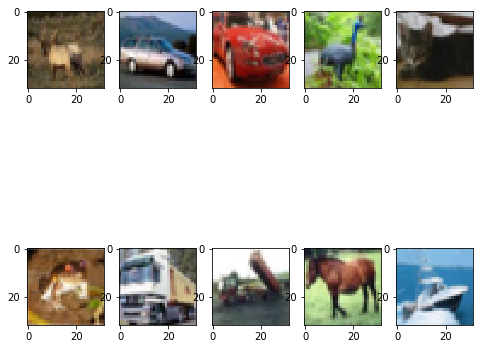

In [0]:
from matplotlib import pyplot as plt
fig, axs = plt.subplots(2,5,figsize=(8,8))

for i in range(0,5):
    axs[0,i].imshow(X_train1[i])
for i in range(0,5):
    axs[1,i].imshow(X_train2[i])

plt.show()

### 2. Use One-hot encoding to divide y_train and y_test into required no of output classes

In [0]:
y_train1_hot = keras.utils.to_categorical(y_train1)
y_train2_hot = keras.utils.to_categorical(y_train2-5)
print(y_train1_hot.shape, y_train2_hot.shape)

y_test1_hot = keras.utils.to_categorical(y_test1)
y_test2_hot = keras.utils.to_categorical(y_test2-5)
print(y_test1_hot.shape, y_test2_hot.shape)

(25000, 5) (25000, 5)
(5000, 5) (5000, 5)


### 3. Build a sequential neural network model which can classify the classes 0 to 4 of CIFAR10 dataset with at least 80% accuracy on test data

In [0]:
model = keras.models.Sequential()
model.add(keras.layers.Conv2D(32, (3, 3), padding='same',
                 input_shape=(32,32,3)))
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Conv2D(32, (3, 3)))
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(keras.layers.Dropout(0.25))

model.add(keras.layers.Conv2D(64, (3, 3), padding='same'))
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Conv2D(64, (3, 3)))
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(keras.layers.Dropout(0.25))

model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(512))
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(5))
model.add(keras.layers.Activation('softmax'))


In [0]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train1, y_train1_hot, batch_size=128, epochs=20,validation_data=(X_test1,y_test1_hot))

Train on 25000 samples, validate on 5000 samples
Epoch 1/20
25000/25000 [==============================] - 114s 5ms/sample - loss: 2.0585 - acc: 0.4243 - val_loss: 1.0243 - val_acc: 0.5734
Epoch 2/20
25000/25000 [==============================] - 114s 5ms/sample - loss: 1.0206 - acc: 0.5847 - val_loss: 0.9023 - val_acc: 0.6428
Epoch 3/20
25000/25000 [==============================] - 114s 5ms/sample - loss: 0.9380 - acc: 0.6274 - val_loss: 0.8393 - val_acc: 0.6624
Epoch 4/20
25000/25000 [==============================] - 113s 5ms/sample - loss: 0.8620 - acc: 0.6557 - val_loss: 0.8054 - val_acc: 0.6800
Epoch 5/20
25000/25000 [==============================] - 114s 5ms/sample - loss: 0.7881 - acc: 0.6944 - val_loss: 0.7296 - val_acc: 0.7178
Epoch 6/20
25000/25000 [==============================] - 114s 5ms/sample - loss: 0.7385 - acc: 0.7159 - val_loss: 0.6854 - val_acc: 0.7360
Epoch 7/20
25000/25000 [==============================] - 114s 5ms/sample - loss: 0.7028 - acc: 0.7340 - val_lo

### 4. In the model which was built above (for classification of classes 0-4 in CIFAR10), make only the dense layers to be trainable and conv layers to be non-trainable

In [0]:
for layer in model.layers:
    if layer.name.find("dense") >= 0:
        print("Setting", layer.name, "trainalble = True")
        layer.trainable=True
    else:
        print("Setting", layer.name, "trainalble = False")
        layer.trainable=False
model.summary()

Setting conv2d_4 trainalble = False
Setting activation_6 trainalble = False
Setting conv2d_5 trainalble = False
Setting activation_7 trainalble = False
Setting max_pooling2d_2 trainalble = False
Setting dropout_3 trainalble = False
Setting conv2d_6 trainalble = False
Setting activation_8 trainalble = False
Setting conv2d_7 trainalble = False
Setting activation_9 trainalble = False
Setting max_pooling2d_3 trainalble = False
Setting dropout_4 trainalble = False
Setting flatten_1 trainalble = False
Setting dense_2 trainalble = True
Setting activation_10 trainalble = False
Setting dropout_5 trainalble = False
Setting dense_3 trainalble = True
Setting activation_11 trainalble = False
Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_4 (Conv2D)            (None, 32, 32, 32)        896       
_________________________________________________________________
activation_6 (Activation) 

### 5. Utilize the the model trained on CIFAR 10 (classes 0 to 4) to classify the classes 5 to 9 of CIFAR 10  (Use Transfer Learning) <br>
Achieve an accuracy of more than 85% on test data

In [0]:
model.fit(X_train2, y_train2_hot, batch_size=128, epochs=10,validation_data=(X_test2, y_test2_hot))

Train on 25000 samples, validate on 5000 samples
Epoch 1/10
25000/25000 [==============================] - 124s 5ms/sample - loss: 1.1041 - acc: 0.5760 - val_loss: 0.6459 - val_acc: 0.7466
Epoch 2/10
25000/25000 [==============================] - 124s 5ms/sample - loss: 0.6695 - acc: 0.7573 - val_loss: 0.5346 - val_acc: 0.8036
Epoch 3/10
25000/25000 [==============================] - 122s 5ms/sample - loss: 0.5656 - acc: 0.7957 - val_loss: 0.4812 - val_acc: 0.8282
Epoch 4/10
25000/25000 [==============================] - 116s 5ms/sample - loss: 0.4909 - acc: 0.8216 - val_loss: 0.4174 - val_acc: 0.8500
Epoch 5/10
25000/25000 [==============================] - 119s 5ms/sample - loss: 0.4405 - acc: 0.8409 - val_loss: 0.3758 - val_acc: 0.8652
Epoch 6/10
25000/25000 [==============================] - 122s 5ms/sample - loss: 0.4035 - acc: 0.8536 - val_loss: 0.3510 - val_acc: 0.8706
Epoch 7/10
25000/25000 [==============================] - 119s 5ms/sample - loss: 0.3833 - acc: 0.8635 - val_lo

# Text classification using TF-IDF

### 6. Load the dataset from sklearn.datasets

In [0]:
from sklearn.datasets import fetch_20newsgroups

In [0]:
categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']

### 7. Training data

In [3]:
twenty_train = fetch_20newsgroups(subset='train', categories=categories, shuffle=True, random_state=42)

### 8. Test data

In [0]:
twenty_test = fetch_20newsgroups(subset='test', categories=categories, shuffle=True, random_state=42)

###  a.  You can access the values for the target variable using .target attribute 
###  b. You can access the name of the class in the target variable with .target_names


In [5]:
twenty_train.target

array([1, 1, 3, ..., 2, 2, 2])

In [6]:
twenty_train.target_names

['alt.atheism', 'comp.graphics', 'sci.med', 'soc.religion.christian']

In [7]:
twenty_train.data[0:5]

['From: sd345@city.ac.uk (Michael Collier)\nSubject: Converting images to HP LaserJet III?\nNntp-Posting-Host: hampton\nOrganization: The City University\nLines: 14\n\nDoes anyone know of a good way (standard PC application/PD utility) to\nconvert tif/img/tga files into LaserJet III format.  We would also like to\ndo the same, converting to HPGL (HP plotter) files.\n\nPlease email any response.\n\nIs this the correct group?\n\nThanks in advance.  Michael.\n-- \nMichael Collier (Programmer)                 The Computer Unit,\nEmail: M.P.Collier@uk.ac.city                The City University,\nTel: 071 477-8000 x3769                      London,\nFax: 071 477-8565                            EC1V 0HB.\n',
 "From: ani@ms.uky.edu (Aniruddha B. Deglurkar)\nSubject: help: Splitting a trimming region along a mesh \nOrganization: University Of Kentucky, Dept. of Math Sciences\nLines: 28\n\n\n\n\tHi,\n\n\tI have a problem, I hope some of the 'gurus' can help me solve.\n\n\tBackground of the probl

### 9.  Now with dependent and independent data available for both train and test datasets, using TfidfVectorizer fit and transform the training data and test data and get the tfidf features for both

In [0]:
from sklearn.feature_extraction.text import TfidfVectorizer
vect = TfidfVectorizer()

In [0]:
twenty_train_dtm = vect.fit_transform(twenty_train.data)
twenty_test_dtm = vect.transform(twenty_test.data)

### 10. Use logisticRegression with tfidf features as input and targets as output and train the model and report the train and test accuracy score

In [0]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()

In [11]:
logreg.fit(twenty_train_dtm, twenty_train.target)

/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:432: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:469: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)


LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='warn', n_jobs=None, penalty='l2',
                   random_state=None, solver='warn', tol=0.0001, verbose=0,
                   warm_start=False)

In [0]:
y_pred = logreg.predict(twenty_test_dtm)

In [13]:
from sklearn import metrics
metrics.accuracy_score(twenty_test.target, y_pred)

0.8868175765645806

In [14]:
y_pred = logreg.predict(twenty_train_dtm)
metrics.accuracy_score(twenty_train.target, y_pred)

0.9827204253433761